In [6]:
%%capture
!az config set core.login_experience_v2=off
!az login


In [75]:
import os
import io
from datetime import datetime, timedelta

import requests
import pystac_client
from pystac import Asset, Collection, ItemCollection
import rioxarray
import xarray as xr
from azure.identity import AzureCliCredential
import ipywidgets as widgets
from IPython.display import display, Image
from ipywidgets import VBox, HBox
from tqdm.notebook import tqdm, trange
import matplotlib.pyplot as plt
import imageio.v2 as imageio


In [12]:
# disable some pesky GDAL warnings/messages
os.environ["CPL_LOG"] = "OFF"

# devseed spatio geocatalog
geocatalog_url = "https://devseed.czh5gshbgkbfajbs.uksouth.geocatalog.spatio.azure.com"

# Function to get a bearer token for the Spatio API
SPATIO_APP_ID = "https://geocatalog.spatio.azure.com"

_access_token = None
def getBearerToken():
    global _access_token
    if not _access_token or datetime.fromtimestamp(_access_token.expires_on) < datetime.now() + timedelta(minutes=5):
        credential = AzureCliCredential()
        _access_token = credential.get_token(f"{SPATIO_APP_ID}/.default")

    return {"Authorization": f"Bearer {_access_token.token}"}

def sign_request(request: requests.Request) -> requests.Request:
    request.params["sign"] = "true"
    return request



In [13]:
# open the Spatio catalog and add the authorization header and flag to sign hrefs with SAS token
catalog = pystac_client.Client.open(f"{geocatalog_url}/api", headers=getBearerToken(), request_modifier=sign_request)


# check out the noaa-hrrr-sfc-conus collection
collection = catalog.get_collection("noaa-hrrr-sfc-conus")

In [14]:
# perform a search to get the full 48 hour forecast (plus the zero-hour forecast) for a point in time
now = datetime(year=2024, month=6, day=25, hour=12)

search = catalog.search(
    collections="noaa-hrrr-sfc-conus",
    sortby="datetime",
    filter={
        "op": "and",
        "args": [
            {
                "op": "eq",
                "args": [{"property": "forecast:horizon"}, "PT48H"]
            },
            {
                "op": "gte",
                "args": [{"property": "forecast:reference_time"}, (now - timedelta(days=4)).strftime("%Y-%m-%dT%H:%M:%SZ")],
            },
        ],
    }
)

# get the forecast that was generated most recently
most_recent_48_hour_forecast_item = sorted(
    search.item_collection(),
    key=lambda item: datetime.strptime(item.properties["forecast:reference_time"], "%Y-%m-%dT%H:%M:%SZ"),
    reverse=True
)[0]

# now search for all items with that reference time
search = catalog.search(
    collections="noaa-hrrr-sfc-conus",
    filter={
        "op": "eq",
        "args": [{"property": "forecast:reference_time"}, most_recent_48_hour_forecast_item.properties["forecast:reference_time"]]
    },
)

item_collection = search.item_collection()
print(f"retrieved {len(item_collection)} items")

retrieved 49 items


The HRRR predictions are distributed in the GRIB2 format. GRIB2 files have many different layers encoded as "messages" that are strung together. Fortunately each GRIB file is accompanied by a .grib.idx index file that describes the byte ranges for each of the messages/layers. We can use the /vsisubfile and GRIB drivers from GDAL to perform targeted reads on the raw files. We could also use the vrt:// syntax with a band index, but that does not work with the signed URLs.



In [ ]:

# identify the grib:layers key for the wind speed variable
{key: info for key, info in collection.ext.item_assets["grib"].properties["grib:layers"].items()}


{'DPT__500_mb__point_in_time': {'unit': 'K',
  'level': '500 mb',
  'variable': 'DPT',
  'description': 'Dew Point Temperature',
  'forecast_layer_type': 'point_in_time'},
 'DPT__700_mb__point_in_time': {'unit': 'K',
  'level': '700 mb',
  'variable': 'DPT',
  'description': 'Dew Point Temperature',
  'forecast_layer_type': 'point_in_time'},
 'DPT__850_mb__point_in_time': {'unit': 'K',
  'level': '850 mb',
  'variable': 'DPT',
  'description': 'Dew Point Temperature',
  'forecast_layer_type': 'point_in_time'},
 'DPT__925_mb__point_in_time': {'unit': 'K',
  'level': '925 mb',
  'variable': 'DPT',
  'description': 'Dew Point Temperature',
  'forecast_layer_type': 'point_in_time'},
 'HGT__500_mb__point_in_time': {'unit': 'gpm',
  'level': '500 mb',
  'variable': 'HGT',
  'description': 'Geopotential Height',
  'forecast_layer_type': 'point_in_time'},
 'HGT__700_mb__point_in_time': {'unit': 'gpm',
  'level': '700 mb',
  'variable': 'HGT',
  'description': 'Geopotential Height',
  'forecast

That's a lot of variables! Let's get a list of just the descriptions:

In [32]:
hrrr_vars = {key: info for key, info in collection.ext.item_assets["grib"].properties["grib:layers"].items()}
hrrr_vars 


/Users/zacdez/Documents/github/PlanetaryComputerExamples/.venv/lib/python3.11/site-packages/pystac/extensions/item_assets.py:52: DeprecatedWarning: The ``item_assets`` extension is deprecated. ``item_assets`` is now a top-level property of ``Collection``.
  warnings.warn(


{'DPT__500_mb__point_in_time': {'unit': 'K',
  'level': '500 mb',
  'variable': 'DPT',
  'description': 'Dew Point Temperature',
  'forecast_layer_type': 'point_in_time'},
 'DPT__700_mb__point_in_time': {'unit': 'K',
  'level': '700 mb',
  'variable': 'DPT',
  'description': 'Dew Point Temperature',
  'forecast_layer_type': 'point_in_time'},
 'DPT__850_mb__point_in_time': {'unit': 'K',
  'level': '850 mb',
  'variable': 'DPT',
  'description': 'Dew Point Temperature',
  'forecast_layer_type': 'point_in_time'},
 'DPT__925_mb__point_in_time': {'unit': 'K',
  'level': '925 mb',
  'variable': 'DPT',
  'description': 'Dew Point Temperature',
  'forecast_layer_type': 'point_in_time'},
 'HGT__500_mb__point_in_time': {'unit': 'gpm',
  'level': '500 mb',
  'variable': 'HGT',
  'description': 'Geopotential Height',
  'forecast_layer_type': 'point_in_time'},
 'HGT__700_mb__point_in_time': {'unit': 'gpm',
  'level': '700 mb',
  'variable': 'HGT',
  'description': 'Geopotential Height',
  'forecast

In [35]:
climate_risk_keys = ["temperature", "precipitation", "wind"]

filtered_hrrr_vars = {
    key: val
    for key, val in hrrr_vars.items()
    if isinstance(val.get("description"), str)
    and any(risk_key in val["description"].lower() for risk_key in climate_risk_keys)
}
filtered_hrrr_vars

{'DPT__500_mb__point_in_time': {'unit': 'K',
  'level': '500 mb',
  'variable': 'DPT',
  'description': 'Dew Point Temperature',
  'forecast_layer_type': 'point_in_time'},
 'DPT__700_mb__point_in_time': {'unit': 'K',
  'level': '700 mb',
  'variable': 'DPT',
  'description': 'Dew Point Temperature',
  'forecast_layer_type': 'point_in_time'},
 'DPT__850_mb__point_in_time': {'unit': 'K',
  'level': '850 mb',
  'variable': 'DPT',
  'description': 'Dew Point Temperature',
  'forecast_layer_type': 'point_in_time'},
 'DPT__925_mb__point_in_time': {'unit': 'K',
  'level': '925 mb',
  'variable': 'DPT',
  'description': 'Dew Point Temperature',
  'forecast_layer_type': 'point_in_time'},
 'TMP__500_mb__point_in_time': {'unit': 'K',
  'level': '500 mb',
  'variable': 'TMP',
  'description': 'Temperature',
  'forecast_layer_type': 'point_in_time'},
 'TMP__700_mb__point_in_time': {'unit': 'K',
  'level': '700 mb',
  'variable': 'TMP',
  'description': 'Temperature',
  'forecast_layer_type': 'point

In [39]:
selected_hrrr_vars = ['WIND__10_m_above_ground__periodic_max', 'TMP__2_m_above_ground__point_in_time', 'TMP__surface__point_in_time', 'Precipitation Rate', 'APCP__surface__cumulative_acc', 'GUST__surface__point_in_time']
selected_hrrr_vars = {key: info for key, info in collection.ext.item_assets["grib"].properties["grib:layers"].items() if key in selected_hrrr_vars}
selected_hrrr_vars


/Users/zacdez/Documents/github/PlanetaryComputerExamples/.venv/lib/python3.11/site-packages/pystac/extensions/item_assets.py:52: DeprecatedWarning: The ``item_assets`` extension is deprecated. ``item_assets`` is now a top-level property of ``Collection``.
  warnings.warn(


{'TMP__surface__point_in_time': {'unit': 'K',
  'level': 'surface',
  'variable': 'TMP',
  'description': 'Temperature',
  'forecast_layer_type': 'point_in_time'},
 'GUST__surface__point_in_time': {'unit': 'm/s',
  'level': 'surface',
  'variable': 'GUST',
  'description': 'Wind Speed (Gust)',
  'forecast_layer_type': 'point_in_time'},
 'APCP__surface__cumulative_acc': {'unit': 'kg/m^2',
  'level': 'surface',
  'variable': 'APCP',
  'description': 'Total Precipitation',
  'forecast_layer_type': 'cumulative_summary'},
 'TMP__2_m_above_ground__point_in_time': {'unit': 'K',
  'level': '2 m above ground',
  'variable': 'TMP',
  'description': 'Temperature',
  'forecast_layer_type': 'point_in_time'},
 'WIND__10_m_above_ground__periodic_max': {'unit': 'm/s',
  'level': '10 m above ground',
  'variable': 'WIND',
  'description': 'Wind Speed',
  'forecast_layer_type': 'periodic_summary'}}

In [44]:
def format_vsisubfile_path(grib_href: str, start_byte: int, byte_size: int) -> str:
    return f"/vsisubfile/{start_byte}_{byte_size},/vsicurl/{grib_href}"

def xarray_from_item_collection_multi(item_collection: ItemCollection, grib_layer_keys: list[str]) -> xr.Dataset:
    all_layers = []

    for grib_layer_key in grib_layer_keys:
        item_layers = []
        for item in item_collection:
            layer_info = item.assets["grib"].extra_fields["grib:layers"].get(grib_layer_key)
            if layer_info:
                vsisubfile_path = format_vsisubfile_path(
                    item.assets["grib"].href,
                    layer_info["start_byte"],
                    layer_info["byte_size"]
                )
                arr = (
                    rioxarray.open_rasterio(
                        vsisubfile_path,
                        chunks={"band": 1, "x": -1, "y": -1},
                        use_idx="NO",
                    )
                    .squeeze()
                    .assign_coords(
                        time=item.properties["datetime"],
                        reference_datetime=item.properties["forecast:reference_time"],
                        variable=grib_layer_key,
                    )
                    .expand_dims(["time", "variable"])
                )
                item_layers.append(arr)

        if item_layers:
            all_layers.append(xr.concat(item_layers, dim="time"))

    if all_layers:
        return xr.concat(all_layers, dim="variable").sortby("time").chunk(time=1)
    else:
        raise ValueError("No valid layers found in the item collection.")

In [45]:
ds = xarray_from_item_collection_multi(item_collection, list(selected_hrrr_vars.keys()))

In [46]:
ds

<xarray.DataArray (time: 49, variable: 5, y: 1059, x: 1799)> Size: 4GB
dask.array<getitem, shape=(49, 5, 1059, 1799), dtype=float64, chunksize=(1, 1, 1059, 1799), chunktype=numpy.ndarray>
Coordinates:
  * x                   (x) float64 14kB -2.698e+06 -2.695e+06 ... 2.696e+06
  * y                   (y) float64 8kB 1.587e+06 1.584e+06 ... -1.587e+06
  * time                (time) <U20 4kB '2024-06-24T18:00:00Z' ... '2024-06-2...
  * variable            (variable) <U37 740B 'TMP__surface__point_in_time' .....
    band                int64 8B 1
    spatial_ref         int64 8B 0
    reference_datetime  <U20 80B '2024-06-24T18:00:00Z'
Attributes: (12/15)
    GRIB_UNIT:                           [C]
    GRIB_COMMENT:                        Temperature [C]
    GRIB_ELEMENT:                        TMP
    GRIB_SHORT_NAME:                     0-SFC
    GRIB_REF_TIME:                       1719252000
    GRIB_VALID_TIME:                     1719424800
    ...                                  ...
    GRIB_PDS_PDTN:                       0
    GRIB_PDS_TEMPLATE_NUMBERS:           0 0 2 0 83 0 0 0 1 0 0 0 48 1 0 0 0 ...
    GRIB_PDS_TEMPLATE_ASSEMBLED_VALUES:  0 0 2 0 83 0 0 1 48 1 0 0 255 0 0
    scale_factor:                        1.0
    add_offset:                          0.0
    long_name:                           0[-] SFC="Ground or water surface"

In [72]:
def evaluate_conditions(ds, thresholds_raw: dict) -> xr.DataArray:
    """
    Evaluate threshold conditions against a dataset or dataarray.
    Returns a boolean mask where all conditions are True.
    """
    if isinstance(ds, xr.DataArray):
        ds = ds.to_dataset(name='__tmp')  # Wrap in a dataset

    mask = xr.full_like(next(iter(ds.data_vars.values())), True, dtype=bool)

    for var, limits in thresholds_raw.items():
        if var not in ds:
            continue

        var_data = ds[var]
        if 'min' in limits:
            mask &= var_data >= limits['min']
        if 'max' in limits:
            mask &= var_data <= limits['max']

    return mask

In [ ]:
def convert_thresholds(thresholds_cooked):
    # Convert °C to Kelvin
    temp_min_k = thresholds_cooked["Temperature Min (°C)"] + 273.15
    temp_max_k = thresholds_cooked["Temperature Max (°C)"] + 273.15

    # Convert km/h to m/s (1 km/h = 0.27778 m/s)
    wind_mps = thresholds_cooked["Wind Speed (km/h)"] * 0.27778

    # Precipitation rate (mm/hr ≈ kg/m²/hr for water)
    precip_rate = thresholds_cooked["Precipitation Rate (mm/hr)"]

    # Total precipitation (mm ≈ kg/m²)
    total_precip = thresholds_cooked["Total Precipitation (mm)"]

    # Cloud cover stays as percent
    cloud_cover_pct = thresholds_cooked["Cloud Cover (%)"]

    return {
        "TMP__surface__point_in_time": temp_max_k,
        "TMP__2_m_above_ground__point_in_time": temp_max_k,
        "GUST__surface__point_in_time": wind_mps,
        "WIND__10_m_above_ground__periodic_max": wind_mps,
        "APCP__surface__cumulative_acc": total_precip,
        "Precipitation Rate": precip_rate,  # Add this if it maps to a separate var
        "Cloud Cover": cloud_cover_pct,
        "Temperature Min (°C)": temp_min_k,  # Keep for special-cased < logic
    }

In [64]:
variables = {
    "Wind Speed (km/h)": {"default": 40, "min": 0, "max": 100},
    "Precipitation Rate (mm/hr)": {"default": 2, "min": 0, "max": 100},
    "Total Precipitation (mm)": {"default": 10, "min": 0, "max": 100},  # NEW
    "Cloud Cover (%)": {"default": 60, "min": 0, "max": 100},
    "Temperature Min (°C)": {"default": -10, "min": -40, "max": 50},
    "Temperature Max (°C)": {"default": 35, "min": -40, "max": 50},
}

selectors = {}

widgets_list = []
for name, config in variables.items():
    slider = widgets.IntSlider(
        value=config["default"],
        min=config["min"],
        max=config["max"],
        step=1,
        continuous_update=False,
        layout=widgets.Layout(width="300px"),
    )
    label = widgets.Label(value=name, layout=widgets.Layout(width="200px"))
    selectors[name] = slider
    widgets_list.append(HBox([label, slider]))

display(VBox(widgets_list))

In [65]:
slider_thresholds = get_selected_risk_thresholds()
thresholds_raw = convert_thresholds(slider_thresholds)

In [69]:
thresholds_raw

{'TMP__surface__point_in_time': (263.15, 308.15),
 'TMP__2_m_above_ground__point_in_time': (263.15, 308.15),
 'GUST__surface__point_in_time': (0, 11.1112),
 'WIND__10_m_above_ground__periodic_max': (0, 11.1112),
 'APCP__surface__cumulative_acc': (0, 2),
 'Cloud Cover': 60}

In [74]:
mask = evaluate_conditions(ds, thresholds_raw)
mask

<xarray.DataArray '__tmp' (time: 49, variable: 5, y: 1059, x: 1799)> Size: 467MB
dask.array<full_like, shape=(49, 5, 1059, 1799), dtype=bool, chunksize=(1, 1, 1059, 1799), chunktype=numpy.ndarray>
Coordinates:
  * x                   (x) float64 14kB -2.698e+06 -2.695e+06 ... 2.696e+06
  * y                   (y) float64 8kB 1.587e+06 1.584e+06 ... -1.587e+06
  * time                (time) <U20 4kB '2024-06-24T18:00:00Z' ... '2024-06-2...
  * variable            (variable) <U37 740B 'TMP__surface__point_in_time' .....
    band                int64 8B 1
    spatial_ref         int64 8B 0
    reference_datetime  <U20 80B '2024-06-24T18:00:00Z'
Attributes: (12/15)
    GRIB_UNIT:                           [C]
    GRIB_COMMENT:                        Temperature [C]
    GRIB_ELEMENT:                        TMP
    GRIB_SHORT_NAME:                     0-SFC
    GRIB_REF_TIME:                       1719252000
    GRIB_VALID_TIME:                     1719424800
    ...                                  ...
    GRIB_PDS_PDTN:                       0
    GRIB_PDS_TEMPLATE_NUMBERS:           0 0 2 0 83 0 0 0 1 0 0 0 48 1 0 0 0 ...
    GRIB_PDS_TEMPLATE_ASSEMBLED_VALUES:  0 0 2 0 83 0 0 1 48 1 0 0 255 0 0
    scale_factor:                        1.0
    add_offset:                          0.0
    long_name:                           0[-] SFC="Ground or water surface"

<xarray.DataArray (time: 49, variable: 5, y: 1059, x: 1799)> Size: 4GB
dask.array<getitem, shape=(49, 5, 1059, 1799), dtype=float64, chunksize=(1, 1, 1059, 1799), chunktype=numpy.ndarray>
Coordinates:
  * x                   (x) float64 14kB -2.698e+06 -2.695e+06 ... 2.696e+06
  * y                   (y) float64 8kB 1.587e+06 1.584e+06 ... -1.587e+06
  * time                (time) <U20 4kB '2024-06-24T18:00:00Z' ... '2024-06-2...
  * variable            (variable) <U37 740B 'TMP__surface__point_in_time' .....
    band                int64 8B 1
    spatial_ref         int64 8B 0
    reference_datetime  <U20 80B '2024-06-24T18:00:00Z'
Attributes: (12/15)
    GRIB_UNIT:                           [C]
    GRIB_COMMENT:                        Temperature [C]
    GRIB_ELEMENT:                        TMP
    GRIB_SHORT_NAME:                     0-SFC
    GRIB_REF_TIME:                       1719252000
    GRIB_VALID_TIME:                     1719424800
    ...                                  ...
    GRIB_PDS_PDTN:                       0
    GRIB_PDS_TEMPLATE_NUMBERS:           0 0 2 0 83 0 0 0 1 0 0 0 48 1 0 0 0 ...
    GRIB_PDS_TEMPLATE_ASSEMBLED_VALUES:  0 0 2 0 83 0 0 1 48 1 0 0 255 0 0
    scale_factor:                        1.0
    add_offset:                          0.0
    long_name:                           0[-] SFC="Ground or water surface"

In [ ]:
# Function to plot a single frame and return as a BytesIO object
def plot_frame(data, time_idx, title, vmin, vmax, cmap, units_label):
    fig, ax = plt.subplots(figsize=(7,5))
    im = ax.imshow(data.isel(time=time_idx, variable=0), cmap=cmap, vmin=vmin, vmax=vmax)    
    ax.axis("off")

    # Adjust layout to reduce whitespace
    plt.subplots_adjust(left=0.1, right=0.9, top=0.85, bottom=0.25)
    
    # Main title at the top
    fig.suptitle(title, fontsize=12, y=0.92)

    # reference time coordinate at the bottom left
    fig.text(0.1, 0.05, f"reference time: {data.reference_datetime.values}", ha="left", fontsize=10)
    
    # forecast time coordinate at the bottom right
    fig.text(0.95, 0.05, f"forecast time: {data.time.values[time_idx]}", ha="right", fontsize=10)
    
    # Horizontal colorbar below the image
    cbar_ax = fig.add_axes([0.15, 0.15, 0.7, 0.03])
    cbar = plt.colorbar(im, cax=cbar_ax, orientation="horizontal")
    cbar.set_label(units_label, fontsize=10, labelpad=3)
    cbar.ax.xaxis.set_label_position("top")
    
    # Progress bar at the very bottom
    total_frames = data.sizes["time"]
    progress = (time_idx + 1) / total_frames
    progress_bar = plt.Rectangle((0.1, 0.02), progress * 0.8, 0.02, transform=fig.transFigure, color="blue")
    fig.patches.append(progress_bar)
    
    buf = io.BytesIO()
    plt.savefig(buf, format="png", bbox_inches="tight", pad_inches=0.1)
    plt.close(fig)
    buf.seek(0)
    return buf

def render_gif(data: xr.DataArray, title: str, cmap: str, units_label: str, vmin: float = None, vmax: float = None):
    if vmin == None:
        vmin = data.quantile(0.01).item()
    if vmax == None:
      vmax = data.quantile(0.99).item()

    # Create frames in memory
    frames = []
    for t in trange(data.sizes["time"]):
        frame = plot_frame(data, t, title, vmin, vmax, cmap, units_label)
        frames.append(imageio.imread(frame))
    
    # Create a GIF in memory
    gif_bytes = io.BytesIO()
    imageio.mimsave(gif_bytes, frames, format="GIF", duration=0.5, loop = 0)
    gif_bytes.seek(0)
    
    return gif_bytes.read()

  0%|          | 0/49 [00:00<?, ?it/s]

ValueError: Dimensions {'band'} do not exist. Expected one or more of ('time', 'variable', 'y', 'x')

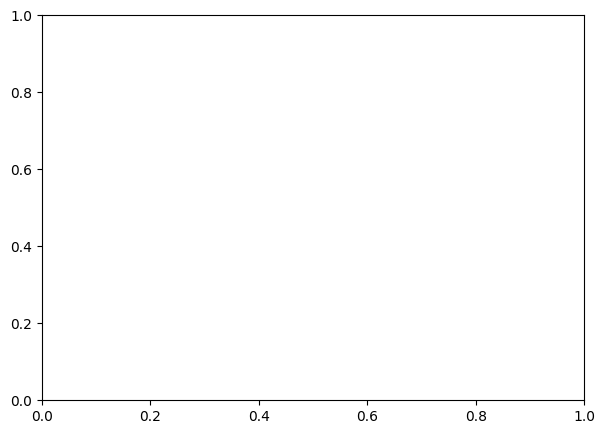

In [85]:
Image(render_gif(mask, "Condition Mask: Winds > 10 m/s", "Greys", "Mask (1 = condition met)", 0, 1))